# Week 2 Day 3 — Key-Rate Durations on Real Bond Data

We test `price_from_curve` and `key_rate_durations` using the CMT yield curve as a real spot rate curve.

**Reminder:** KRDs measure sensitivity to a 1bp tent-function bump at each maturity bucket [2Y, 5Y, 10Y, 30Y]. They should:
- Be positive (price falls when rates rise)
- Sum to approximately modified duration
- Be concentrated near the bond's own maturity

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.termstructure.bonds.pricing import (
    price_from_ytm,
    price_from_curve,
    modified_duration,
    key_rate_durations,
)

## 1. Build the spot rate curve from CMT yields

In [2]:
cmt = pd.read_parquet('../data/processed/cmt_yields.parquet')

latest_date = cmt['date'].max()
print(f'Using date: {latest_date.date()}')

snap = (
    cmt[cmt['date'] == latest_date]
    .sort_values('maturity_years')
    .query('maturity_years >= 1.0')   # exclude T-bills
)

curve_mats  = snap['maturity_years'].values
curve_rates = snap['yield_pct'].values / 100

print('Curve grid:')
for m, r in zip(curve_mats, curve_rates):
    print(f'  {m:5.1f}Y  {r*100:.3f}%')

Using date: 2020-12-31
Curve grid:
    1.0Y  0.100%
    2.0Y  0.130%
    5.0Y  0.360%
   10.0Y  0.930%
   30.0Y  1.650%


## 2. price_from_curve vs price_from_ytm on a flat curve

As a sanity check, if we feed `price_from_curve` a flat curve (same rate at every maturity), it must match `price_from_ytm` exactly. The CMT curve is not flat, so this test uses a synthetic flat curve at 5%.

In [3]:
flat_rates = np.full_like(curve_rates, 0.05)

for mat in [2, 5, 10, 30]:
    p_ytm   = price_from_ytm(0.05, mat, 0.05)
    p_curve = price_from_curve(0.05, mat, curve_mats, flat_rates)
    print(f'{mat:2d}Y  price_from_ytm={p_ytm:.6f}  price_from_curve={p_curve:.6f}  diff={abs(p_ytm-p_curve):.2e}')

 2Y  price_from_ytm=100.000000  price_from_curve=100.000000  diff=0.00e+00
 5Y  price_from_ytm=100.000000  price_from_curve=100.000000  diff=0.00e+00
10Y  price_from_ytm=100.000000  price_from_curve=100.000000  diff=1.42e-14
30Y  price_from_ytm=100.000000  price_from_curve=100.000000  diff=0.00e+00


## 3. Price par bonds off the real CMT curve

Now we use the actual CMT curve. A bond whose coupon equals the YTM priced off a *flat* curve is par. But when we price the same bond off the *real* (upward-sloping or inverted) curve, the price won't be exactly 100 — the curve shape matters.

In [4]:
maturities = [2, 5, 10, 30]

rows = []
for mat in maturities:
    # Coupon = CMT yield at that maturity (interpolated)
    coupon = float(np.interp(mat, curve_mats, curve_rates))
    p = price_from_curve(coupon, mat, curve_mats, curve_rates)
    rows.append({'Maturity (Y)': mat, 'Coupon (%)': round(coupon*100, 3), 'Price': round(p, 6)})

pd.DataFrame(rows)

,Maturity (Y),Coupon (%),Price
0,2,0.13,100.000044
1,5,0.36,100.005422
2,10,0.93,100.161988
3,30,1.65,102.348712


## 4. Key-rate durations across the curve

For each bond, we compute KRDs at the [2Y, 5Y, 10Y, 30Y] buckets. The key things to observe:
- Each bond's KRD is heaviest at its own maturity bucket
- KRDs sum to approximately the modified duration
- A 2Y bond has almost zero KRD at 10Y and 30Y — it simply has no cash flows there

In [5]:
bucket_points = [2, 5, 10, 30]
results = []

for mat in maturities:
    coupon = float(np.interp(mat, curve_mats, curve_rates))
    ytm    = float(np.interp(mat, curve_mats, curve_rates))  # flat-curve approx
    
    krds = key_rate_durations(coupon, mat, curve_mats, curve_rates, bucket_points)
    md   = modified_duration(coupon, mat, ytm)
    
    row = {'Bond': f'{mat}Y', 'Mod Dur': round(md, 3)}
    for bp, krd in krds.items():
        row[f'KRD {bp}Y'] = round(krd, 3)
    row['KRD Sum'] = round(sum(krds.values()), 3)
    results.append(row)

df = pd.DataFrame(results).set_index('Bond')
df

,Mod Dur,KRD 2Y,KRD 5Y,KRD 10Y,KRD 30Y,KRD Sum
Bond,,,,,,
2Y,1.997,1.997,0.000,0.000,0.000,1.997
5Y,4.951,0.023,4.928,0.000,0.000,4.951
10Y,9.528,0.060,0.203,9.259,0.000,9.522
30Y,23.587,0.103,0.353,2.451,20.459,23.365


## 5. Visualise KRD profiles

Each bond shows its interest-rate risk "fingerprint" — where on the curve it is exposed.

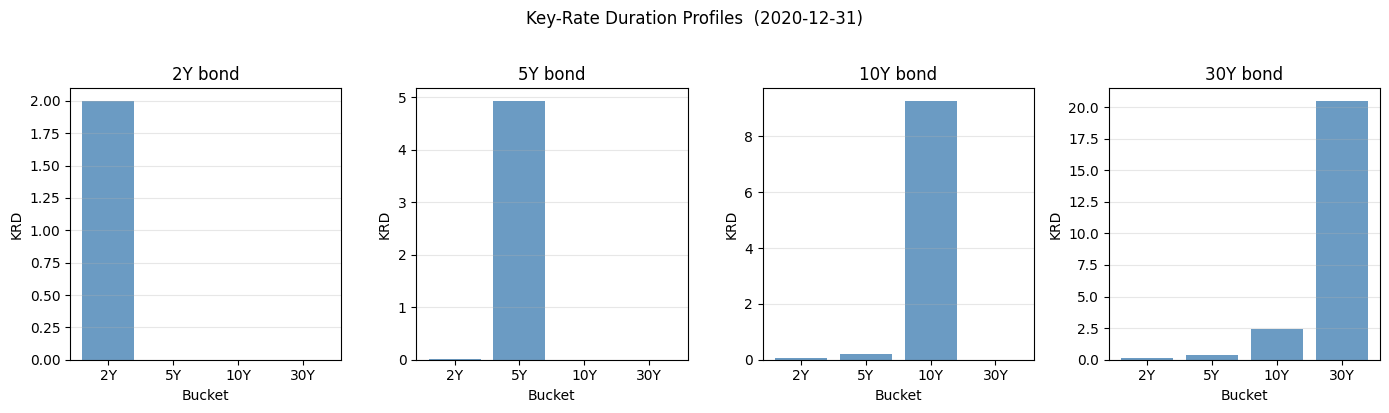

In [6]:
fig, axes = plt.subplots(1, len(maturities), figsize=(14, 4), sharey=False)

for ax, row in zip(axes, results):
    krd_vals = [row[f'KRD {bp}Y'] for bp in bucket_points]
    ax.bar([str(bp)+'Y' for bp in bucket_points], krd_vals, color='steelblue', alpha=0.8)
    ax.set_title(f"{row['Bond']} bond")
    ax.set_xlabel('Bucket')
    ax.set_ylabel('KRD')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Key-Rate Duration Profiles  ({latest_date.date()})', y=1.02)
plt.tight_layout()
plt.show()

## 6. KRD sum vs modified duration

Summing all KRDs should recover approximately the modified duration. Any difference comes from the tent functions not perfectly covering the full curve (especially for maturities outside [2Y, 30Y]).

In [7]:
check = df[['Mod Dur', 'KRD Sum']].copy()
check['Difference'] = (check['KRD Sum'] - check['Mod Dur']).abs().round(4)
check

,Mod Dur,KRD Sum,Difference
Bond,,,
2Y,1.997,1.997,0.000
5Y,4.951,4.951,0.000
10Y,9.528,9.522,0.006
30Y,23.587,23.365,0.222


## 7. Hedging intuition — match KRDs to neutralise curve risk

Suppose you're long a 10Y bond and want to hedge it with a 2Y and 30Y bond.
The hedge weights solve: make the portfolio's KRD at every bucket equal to zero.

This is a preview of Week 6 — but let's see the numbers now.

In [8]:
# KRDs of the 10Y bond (the position we want to hedge)
c10  = float(np.interp(10, curve_mats, curve_rates))
krd_10 = key_rate_durations(c10, 10, curve_mats, curve_rates, bucket_points)

# KRDs of the two hedge instruments: 2Y and 30Y bonds
c2   = float(np.interp(2,  curve_mats, curve_rates))
c30  = float(np.interp(30, curve_mats, curve_rates))
krd_2  = key_rate_durations(c2,  2,  curve_mats, curve_rates, bucket_points)
krd_30 = key_rate_durations(c30, 30, curve_mats, curve_rates, bucket_points)

print('10Y bond KRDs:', {k: round(v,3) for k,v in krd_10.items()})
print('2Y  bond KRDs:', {k: round(v,3) for k,v in krd_2.items()})
print('30Y bond KRDs:', {k: round(v,3) for k,v in krd_30.items()})
print()
print('To hedge the 10Y, we need short positions in the 2Y and 30Y')
print('whose KRDs cancel the 10Y KRDs at each bucket.')
print('Week 6 will solve this as a linear system.')

10Y bond KRDs: {2: 0.06, 5: 0.203, 10: 9.259, 30: 0.0}
2Y  bond KRDs: {2: 1.997, 5: 0.0, 10: 0.0, 30: 0.0}
30Y bond KRDs: {2: 0.103, 5: 0.353, 10: 2.451, 30: 20.459}

To hedge the 10Y, we need short positions in the 2Y and 30Y
whose KRDs cancel the 10Y KRDs at each bucket.
Week 6 will solve this as a linear system.
